In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier


In [ ]:
data_path = "../../data/Student_performance_data _.csv"
df = pd.read_csv(data_path)
print(df.columns.tolist())

['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


In [14]:

target_col = "GradeClass"
drop_cols = ["StudentID"]  # ID nuk e perdorim si feature

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target value counts:")
print(y.value_counts())


X shape: (2392, 13)
y shape: (2392,)
Target value counts:
GradeClass
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64


In [15]:
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)
print("Classes:", label_enc.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Classes: [0. 1. 2. 3. 4.]
Train shape: (1913, 13)
Test shape: (479, 13)


In [16]:

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']
Categorical features: []


In [17]:

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),                 # i njejte per krejt klasifikuesit
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [18]:

rf_param_grid = {
    "feature_selection__k": [3, 5, 7, 10, "all"],     # sa veçori me mbajt

    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__max_features": ["sqrt", "log2"],
}

In [ ]:

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

rf_grid_search.fit(X_train, y_train)

print("Best Parameters (Random Forest):")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation F1 Macro (Random Forest):")
print(rf_grid_search.best_score_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [ ]:

rf_best_model = rf_grid_search.best_estimator_
rf_y_pred = rf_best_model.predict(X_test)

In [10]:

rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred, average="macro")
rf_recall = recall_score(y_test, rf_y_pred, average="macro")
rf_f1 = f1_score(y_test, rf_y_pred, average="macro")

print("\nRandom Forest - Test Metrics:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision (macro): {rf_precision:.4f}")
print(f"Recall (macro): {rf_recall:.4f}")
print(f"F1-score (macro): {rf_f1:.4f}")

print("\nRandom Forest - Classification Report:")
print(classification_report(y_test, rf_y_pred, target_names=[str(c) for c in label_enc.classes_]))


Random Forest - Test Metrics:
Accuracy: 0.9248
Precision (macro): 0.9287
Recall (macro): 0.8448
F1-score (macro): 0.8717

Random Forest - Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.52      0.69        21
         1.0       0.91      0.89      0.90        54
         2.0       0.90      0.95      0.93        78
         3.0       0.89      0.89      0.89        83
         4.0       0.94      0.97      0.96       243

    accuracy                           0.92       479
   macro avg       0.93      0.84      0.87       479
weighted avg       0.93      0.92      0.92       479



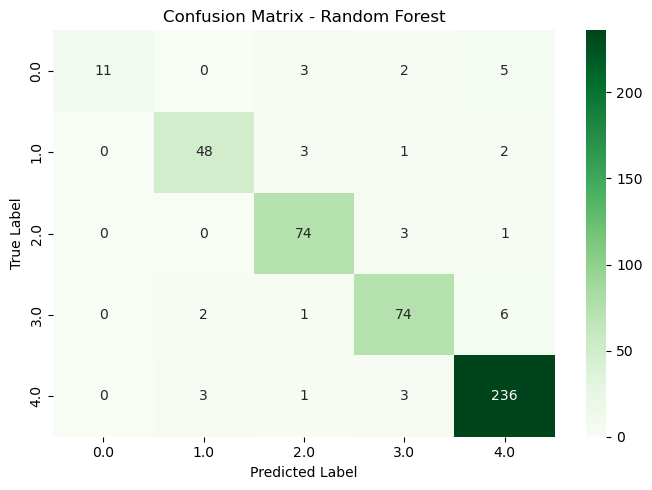

PermissionError: [Errno 13] Permission denied: '../../visualizations'

In [11]:

rf_cm = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_enc.classes_,
    yticklabels=label_enc.classes_
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


os.makedirs("visualizations", exist_ok=True)

plt.figure(figsize=(7, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_enc.classes_,
    yticklabels=label_enc.classes_
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("visualizations/random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:



rf_results_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "Best_Params": [str(rf_grid_search.best_params_)],
    "CV_F1_Macro": [rf_grid_search.best_score_],
    "Test_Accuracy": [rf_accuracy],
    "Test_Precision_Macro": [rf_precision],
    "Test_Recall_Macro": [rf_recall],
    "Test_F1_Macro": [rf_f1]
})

os.makedirs("results", exist_ok=True)
results_df.to_csv("results/random_forest_results.csv", index=False)
print("Results saved to results/random_forest_results.csv")